In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots
using LinearAlgebra

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


En primer lugar se genera el QTT de n sites correspondiente a un vector con N=2^n elementos que tiene un fondo $2\beta-\alpha$, pero cuyo primer elemento vale $-\alpha-\gamma+\beta$ y su último elemento vale $\beta-\alpha$. Este vector es el resultado de aplicar, sobre un vector formado por N unos, una matriz tridiagonal simétrica que tiene $\beta$ en las diagonales secundarias (N-1 elementos) y $-\alpha+\beta$ en la diagonal principal (N elementos), excepto el primer que es $-\alpha-\gamma$. El objectiu es resolver el sistema a partir del MPO y este MPS para recuperar los unos. Esto se realizará mediante DMRG. A continuación se realizará la evolución temporal mediante TDVP.

Los tres estados de los índices virtuales (links) significan lo siguiente:
<ul>
    <li>Estado 1: "Hasta ahora, la cadena viene siendo puramente de ceros (∣00…0⟩)."</li>
    <li>Estado 2: "La cadena ya se mezcló (tiene ceros y unos). Estamos en el ($2\beta-\alpha$)."</li>
    <li>Estado 3: "Hasta ahora, la cadena viene siendo puramente de unos (∣11…1⟩)."</li>
</ul>
Los sitios 1 a n−1 actúan como un detector lógico: Solo registran si el camino de bits es homogéneo (ceros o unos) o si ya se mezcló.

El sitio n actúa como el evaluador numérico: Lee el diagnóstico que le llega del resto de la cadena y asigna el valor físico real.

<b>El primer sitio</b> mira el primer bit y abre el camino correcto. Si es un cero, es el estado 1 y si es 1, es el estado 3. A cada estado le corresponde un elemento del vector fila que define el sitio: $M_1[0]=(1 \ 0 \ 0),M_1[1]=(0 \ 0 \ 1)$.

<b>En los sitios intermedios</b>, si el bit leido es 0, ya no puede ser Estado 3 (se bloquea).  Las filas desde las cuales se accede indican el estado en el que se llega. Las columnas representan el estado al que se pasa. A continuación se resume el comportamiento: 
<ul>
    <li>Fila 1: Si venía de Estado 1 y lee un 0, sigue en Estado 1. La fila completa es: (1 0 0)</li>
<li>Fila 2: Si ya venía mezclado (Estado 2) y lee un 0, sigue mezclado (Estado 2). La fila completa es: (0 1 0)</li>
<li>Fila 3: Si venía puro unos (3) y lee un 0, ¡se rompe la pureza! La matriz lo desvía automáticamente al canal mezclado (2). La pila completa es: (0 0 1)</li>
</ul>
Sin embargo, si el bit leido es 1, no puede ser Estado 1 (también se bloquea). De nuevo,se tiene una matriz cuyas filas denotan el estado del que se viene y las columnas son el estado al que se pasa. A continuación se tiene el comportamiento en este segundo caso:
<ul>
<li>Fila 1: Si venía de Estado 1 y lee un 1, ¡se rompe la pureza! Lo desvía al canal mezclado o Estado 2. La fila de la matriz es: (0 1 0)</li>
    <li>Fila 2: Si ya venía mezclado (Estado 2) y lee un 1, sigue mezclado (Estado 2). La fila de la matriz es: (0 1 0)</li>
    <li>Fila 3: Si venía de Estado 3 y lee un 1, sigue en Estado 3. La fila de la matriz es: (0 0 1)</li>
</ul>

<b>En el último sitio</b>, si el último bit es 0:
<ul>
<li>Si el link traía el Estado 1: Significa que todos los bits anteriores fueron 0, y como el último también es 0, estamos ante el mismísimo primer elemento del vector. El MPS devuelve $-\alpha-\gamma+\beta$.</li>
<li>Si el link traía el Estado 2 ó 3: Significa que en algún punto hubo una mezcla (o venía de puros unos y cayó a cero al final). De cualquier forma, caímos en el fondo constante, así que devuelve $−\alpha+2\beta$.</li>
</ul>
Esto significa que en el último sitio se tiene una columna cuyos elementos son $(-\alpha-\gamma+\beta,−\alpha+2\beta, −\alpha+2\beta)^T$
En cambio, si el último bit es 1: 
<ul>
<li>Si el link traía el Estado 1 ó 2: Hubo mezcla en el camino (o venía de puros ceros y subió a uno al final). Devuelve el fondo constante −α+2β.</li>
<li>Si el link traía el Estado 3: Todos los bits anteriores fueron 1, y como el último también es 1, estamos ante el último elemento del vector. El MPS devuelve β−α.</li>
</ul>
Esto significa que en el último sitio se tiene una columna cuyos elementos son $(−\alpha+2\beta, −\alpha+2\beta,−\alpha+\beta)^T$

In [2]:
function generate_qtt_mps_perfect(n::Int, α::Float64, β::Float64, γ::Float64)
    sites = siteinds("Qubit", n)
    links = [Index(3, "Link,l=$i") for i in 1:(n-1)]
    mps = MPS(sites)
    
    # Sitio 1
    M1 = ITensor(sites[1], links[1])
    M1[sites[1]=>1, links[1]=>1] = 1.0
    M1[sites[1]=>2, links[1]=>3] = 1.0
    mps[1] = M1
    
    # Sitios Centrales
    for i in 2:(n-1)
        Mi = ITensor(links[i-1], sites[i], links[i])
        Mi[links[i-1]=>1, sites[i]=>1, links[i]=>1] = 1.0
        Mi[links[i-1]=>2, sites[i]=>1, links[i]=>2] = 1.0
        Mi[links[i-1]=>3, sites[i]=>1, links[i]=>2] = 1.0
        
        Mi[links[i-1]=>1, sites[i]=>2, links[i]=>2] = 1.0
        Mi[links[i-1]=>2, sites[i]=>2, links[i]=>2] = 1.0
        Mi[links[i-1]=>3, sites[i]=>2, links[i]=>3] = 1.0
        mps[i] = Mi
    end
    
    # Sitio N
    Mn = ITensor(links[n-1], sites[n])
    fondo = 2β - α
    Mn[links[n-1]=>1, sites[n]=>1] = -α - γ + β
    Mn[links[n-1]=>2, sites[n]=>1] = fondo
    Mn[links[n-1]=>3, sites[n]=>1] = fondo
    
    Mn[links[n-1]=>1, sites[n]=>2] = fondo
    Mn[links[n-1]=>2, sites[n]=>2] = fondo
    Mn[links[n-1]=>3, sites[n]=>2] = β - α
    mps[n] = Mn
    
    return mps, sites
end

# --- FUNCIÓN PARA GENERAR EL VECTOR COMPLETO DENSO,PARA COMPROBAR---
function mps_to_dense_vector(mps::MPS, sites)
    n = length(mps)
    N = 2^n
    vec_denso = zeros(Float64, N)
    
    # Recorremos los 2^n elementos posibles
    for idx in 1:N
        # Convertir el índice a binario (0 y 1) como strings para ITensor
        # "0" corresponde al primer estado físico, "1" al segundo
        bin_str = [string(c) for c in string(idx - 1, base=2, pad=n)]
        
        # Creamos el estado de la base del elemento actual (ej: |0100⟩)
        # IMPORTANTE: Reutilizamos 'sites' para que los índices coincidan exactamente
        p_state = MPS(sites, bin_str)
        
        # El producto interno nos da el valor exacto de esa componente
        vec_denso[idx] = inner(mps, p_state)
    end
    
    return vec_denso
end

# --- EJECUCIÓN Y DEMOSTRACIÓN ---
n = 4 # Un espacio de Hilbert de 2^4 = 16 elementos
α, β, γ = 1.0, 2.0, 0.5

mps, sites = generate_qtt_mps_perfect(n, α, β, γ)
vector_denso = mps_to_dense_vector(mps, sites)

# Imprimir el vector con sus etiquetas binarias para verificar
println("Vector completo generado de tamaño $(length(vector_denso)):")
println("-"^45)
for idx in 1:length(vector_denso)
    # Convertir el índice (1 a 2^n) a formato binario de n bits (ej: "0100")
    # Nota: Julia cuenta desde 1, restamos 1 para la base binaria
    bin_str = string(idx - 1, base=2, pad=n)
    
    # Formatear la salida para que sea fácil de leer
    println("| $bin_str ⟩ = ", vector_denso[idx])
end
println("-"^45)

Vector completo generado de tamaño 16:
---------------------------------------------
| 0000 ⟩ = 0.5
| 0001 ⟩ = 3.0
| 0010 ⟩ = 3.0
| 0011 ⟩ = 3.0
| 0100 ⟩ = 3.0
| 0101 ⟩ = 3.0
| 0110 ⟩ = 3.0
| 0111 ⟩ = 3.0
| 1000 ⟩ = 3.0
| 1001 ⟩ = 3.0
| 1010 ⟩ = 3.0
| 1011 ⟩ = 3.0
| 1100 ⟩ = 3.0
| 1101 ⟩ = 3.0
| 1110 ⟩ = 3.0
| 1111 ⟩ = 1.0
---------------------------------------------


El siguiente paso es la construcción del MPO, construido a partir de una matriz tridiagonal toeplitz simétrica que tiene una anomalía en el primer elemento.

La construcción manual se basa en las máquinas de estados. Hay cuatro posibles estados:
<ul>
    <li>Estado 1 (Identidad): El qubit anterior dice "por aquí no pasa nada raro, solo propago el testigo vacío sin hacer nada (I) para que cualquiera pueda iniciar los cálculos cuando quiera</li>
    <li>Estado 2 (acarreo positivo): Un qubit atrás activó un operador de acarreo positivo, de manera que el qubit anterior le dice al vecino: "Te paso un testimonio $S^+$, necesito que tú te actives en este sitio o más adelante para cerrar el salto"</li>
    <li>Estado 3 (acarreo negativo): Un qubit atrás activó un operador de acarreo negativo, de manera que el qubit anterior le dice al vecino: "Te paso un testimonio $S^-$, necesito que tú te actives en este sitio o más adelante para cerrar el salto"</li>
    <li>Estado 4 (Anomalía primer elemento diagonal: es el canal privado que transporta la condición del primer elemento de la diagonal sin que nadie la contamine.</li>    
</ul>
En el sitio 1, tanto si llega un cero como si llega un 1, se activan en paralelo los cuatro posibles estados, mediante distintos operadores, caracterizados mediante la fila de operadores $$\begin{pmatrix}I& \beta S^+&\beta S^-& -\gamma P_0\end{pmatrix}$$.

En los sitios intermedios, tanto si llega un cero como si llega un uno, pueden suceder diferentes situaciones, dependiendo de los estados de llegada, que se corresponden con las filas de la matriz de operadores. Dentro de cada fila, cada columna se corresponde con uno de los cuatro estados:
<ul>
    <li>Puede seguir propagando la identidad (Estado 1), o decidir que este qubit inicie un salto activando un acarreo positivo (Estado 2) o un acarreo negativo (Estado 3). No puede saltar directamente a Robin (Estado 4). La fila correspondiente es $\begin{pmatrix}I& \beta S^+&\beta S^-&0\end{pmatrix}$</li>
    <li>Si llega en estado 2, recibe el testimonio $S^+$ y cierra el salto en este sitio aplicando $S^-$. Como la interacción termina justo aquí, el estado se descarga y envía un $0$ hacia el futuro. La fila correspondiente es $\begin{pmatrix}0& S^-&0&0\end{pmatrix}$</li>
    <li>Si llega en estado 3, recibe el testimonio $S^-$ y cierra el salto en este sitio aplicando $S^+$. Como la interacción termina justo aquí, el estado se descarga y envía un $0$ hacia el futuro.. La fila correspondiente es $\begin{pmatrix}0& 0&S^+&0\end{pmatrix}$</li>
    <li>Si llega en estado 4, Deja pasar intacta la anomalía midiendo el proyector $P_0$. La fila correspondiente es $\begin{pmatrix}0& 0&0&P_0\end{pmatrix}$</li>
</ul>
Reuniendo las filas, la matriz de operadores intermedios queda:
$$W_i = \begin{pmatrix} 
\mathbb{I} & \beta S^+ & \beta S^- & 0 \\ 
0 & S^- & 0 & 0 \\ 
0 & 0 & S^+ & 0 \\ 
0 & 0 & 0 & P_0 
\end{pmatrix}$$

En el último qubit se recogen y absorben todos los canales abiertos para colapsar el operador en el espacio global a través de un vector columna:
<ul>
    <li>Si llega en estado 1, aplica el final de la diagonal central ($-\alpha \mathbb{I}$) junto con las últimas interacciones locales de este qubit ($\beta S^+ + \beta S^-$).</li>
    <li>Si llega en estado 2, cierra el último acarreo positivo pendiente aplicando $S^-$.</li>
    <li>Si llega en estado 3, cierra el último acarreo negativo pendiente aplicando $S^+$</li>
    <li>Si llega en estado 4, deposita finalmente el proyector $P_0$ de Robin que venía viajando desde el inicio de la cadena.</li>
</ul>
Así pues, el vector columna es: 
$$\begin{pmatrix}-\alpha \mathbb{I}+\beta S^+ + \beta S^-\\S^-\\S^+\\P_0\end{pmatrix}$$

In [3]:
#Funciones para generar vectores y matrices a partir de MPS y MPO respectivamente
function matriz_densa_desde_mpo(mpo, sites)
    L = length(sites)
    N = 2^L
    M = zeros(N, N)
    for col in 0:(N-1)
        ket_bits = [(col >> (L-1-j)) & 1 for j in 0:(L-1)]
        ket = MPS([itensor([1 - ket_bits[j+1], ket_bits[j+1]], sites[j+1]) for j in 0:(L-1)])
        for row in 0:(N-1)
            bra_bits = [(row >> (L-1-j)) & 1 for j in 0:(L-1)]
            bra = MPS([itensor([1 - bra_bits[j+1], bra_bits[j+1]], sites[j+1]) for j in 0:(L-1)])
            M[row+1, col+1] = real(inner(bra', mpo, ket))
        end
    end
    return M
end
function mps_to_dense_vector(mps::MPS, sites)
    n = length(mps)
    N = 2^n
    vec_denso = zeros(Float64, N)
    
    for idx in 1:N
        bin_str = [string(c) for c in string(idx - 1, base=2, pad=n)]
        p_state = MPS(sites, bin_str)
        vec_denso[idx] = inner(mps, p_state)
    end
    
    return vec_denso
end

mps_to_dense_vector (generic function with 1 method)

In [4]:
# =============================================================================
# CONSTRUCCIÓN MANUAL DEL OPERADOR QUE TIENE MATRIZ DENSA TRIDIAGONAL
# =============================================================================
# Acepta los 'sites' del MPS exterior para reusar sus IDs
function construir_mpo_manual_perfecto(sites, alpha::Float64, beta::Float64, gamma::Float64)
    L = length(sites)
    MPO_manual = MPO(sites)
    
    links = [Index(4, "Link,l=$l") for l in 1:(L-1)]
    
    Id = [1.0 0.0; 0.0 1.0]; P0 = [1.0 0.0; 0.0 0.0]; 
    Sp = [0.0 1.0; 0.0 0.0]; Sm = [0.0 0.0; 1.0 0.0]
    
    # --- SITIO 1 ---
    W1 = ITensor(sites[1], prime(sites[1]), links[1])
    for s in 1:2, sp in 1:2
        W1[sites[1]=>s, prime(sites[1])=>sp, links[1]=>1] = Id[s, sp]
        W1[sites[1]=>s, prime(sites[1])=>sp, links[1]=>2] = beta * Sp[s, sp]
        W1[sites[1]=>s, prime(sites[1])=>sp, links[1]=>3] = beta * Sm[s, sp]
        W1[sites[1]=>s, prime(sites[1])=>sp, links[1]=>4] = -gamma * P0[s, sp]
    end
    MPO_manual[1] = W1
    
    # --- SITIOS INTERMEDIOS ---
    for i in 2:(L-1)
        W = ITensor(links[i-1], sites[i], prime(sites[i]), links[i])
        for s in 1:2, sp in 1:2
            W[links[i-1]=>1, sites[i]=>s, prime(sites[i])=>sp, links[i]=>1] = Id[s, sp]
            W[links[i-1]=>1, sites[i]=>s, prime(sites[i])=>sp, links[i]=>2] = beta * Sp[s, sp]
            W[links[i-1]=>1, sites[i]=>s, prime(sites[i])=>sp, links[i]=>3] = beta * Sm[s, sp]
            
            W[links[i-1]=>2, sites[i]=>s, prime(sites[i])=>sp, links[i]=>2] = Sm[s, sp]
            W[links[i-1]=>3, sites[i]=>s, prime(sites[i])=>sp, links[i]=>3] = Sp[s, sp]
            W[links[i-1]=>4, sites[i]=>s, prime(sites[i])=>sp, links[i]=>4] = P0[s, sp]
        end
        MPO_manual[i] = W
    end
    
    # --- SITIO L ---
    WN = ITensor(links[L-1], sites[L], prime(sites[L]))
    for s in 1:2, sp in 1:2
        WN[links[L-1]=>1, sites[L]=>s, prime(sites[L])=>sp] = -alpha * Id[s, sp] + beta * Sp[s, sp] + beta * Sm[s, sp]
        WN[links[L-1]=>2, sites[L]=>s, prime(sites[L])=>sp] = Sm[s, sp]
        WN[links[L-1]=>3, sites[L]=>s, prime(sites[L])=>sp] = Sp[s, sp]
        WN[links[L-1]=>4, sites[L]=>s, prime(sites[L])=>sp] = P0[s, sp]
    end
    MPO_manual[L] = WN
    
    return MPO_manual
end

construir_mpo_manual_perfecto (generic function with 1 method)

El primer experimento es verificar que al aplicar el MPO construido sobre un MPS constante de unos se obtiene el MPS con fondo constante y perturbaciones en los extremos que se ha construido antes

In [5]:
# =============================================================================
# 1. CONFIGURACIÓN DEL EXPERIMENTO DE ESTADO ESTACIONARIO (SISTEMA DE ECUACIONES)
# =============================================================================
n = 6                       # Qubits (N = 64)
α = 2.0; β = 0.5; γ = -1.2   # Constantes físicas de prueba

println("1. Generando estados objetivos y operadores...")
mps_objetivo, sites = generate_qtt_mps_perfect(n, α, β, γ)

# Pasamos 'sites' directamente a la construcción del MPO
MPO_tridiag = construir_mpo_manual_perfecto(sites, α, β, γ)

# =============================================================================
# 2. CREACIÓN DEL MPS DE "TODO UNOS"
# =============================================================================
println("2. Creando el MPS de inicialización de todo 'unos'...")
mps_unos = MPS(sites, ["0" for _ in 1:n])
for i in 1:n
    idx_sitio = inds(mps_unos[i])
    T = ITensor(Float64, idx_sitio...) 
    T .= 1.0                           
    mps_unos[i] = T
end

# =============================================================================
# 3. APLICACIÓN DIRECTA DEL OPERADOR MPO * MPS
# =============================================================================
println("3. Aplicando el MPO de manera directa sobre el vector de unos...")

# Ahora que comparten exactamente los mismos 'sites', la multiplicación funciona al instante
mps_resultado = apply(MPO_tridiag, mps_unos; cutoff=1e-12)

# =============================================================================
# 4. PASO A DENSO Y COMPROBACIÓN DEL ÉXITO DE TU HIPÓTESIS
# =============================================================================
println("4. Convirtiendo a representación densa...")
vec_esperado = mps_to_dense_vector(mps_objetivo, sites)
vec_obtenido = mps_to_dense_vector(mps_resultado, sites)

println("\n==================================================")
println("--- VERIFICACIÓN DIRECTA EXCELENTE ---")
println("==================================================")
println("Primer elemento esperado: ", vec_esperado[1], " | Obtenido: ", vec_obtenido[1])
println("Último elemento esperado: ", vec_esperado[end], " | Obtenido: ", vec_obtenido[end])

error_absoluto = norm(vec_esperado - vec_obtenido)
println("--------------------------------------------------")
println("Error absoluto total en el espacio denso: ", error_absoluto)
println("==================================================")

1. Generando estados objetivos y operadores...
2. Creando el MPS de inicialización de todo 'unos'...
3. Aplicando el MPO de manera directa sobre el vector de unos...
4. Convirtiendo a representación densa...

--- VERIFICACIÓN DIRECTA EXCELENTE ---
Primer elemento esperado: -0.30000000000000004 | Obtenido: -0.29999999999999893
Último elemento esperado: -1.5 | Obtenido: -1.4999999999999991
--------------------------------------------------
Error absoluto total en el espacio denso: 1.7898365378704147e-14


Resolución del Sistema Lineal ($Ax = b$) mediante DMRGUna vez construido el MPO de la matriz tridiagonal $A$ (que incorpora las condiciones de contorno de Robin) y el MPS del vector término fuente $|b\rangle$, el objetivo es hallar el vector solución $|x\rangle$ que satisfaga la ecuación matricial:$$A|x\rangle = |b\rangle$$En el marco de las redes de tensores (y específicamente en la codificación QTT), este problema algebraico se reformula como un problema de optimización variacional.Formulación del problema variacionalEl algoritmo busca el Matrix Product State (MPS) $|x\rangle$ que minimice el cuadrado de la norma del residuo de la ecuación, conocido como función de coste o error cuadrático:$$E(|x\rangle) = \| A|x\rangle - |b\rangle \|^2 = \langle x | A^\dagger A | x \rangle - \langle x | A^\dagger | b \rangle - \langle b | A | x \rangle + \langle b | b \rangle$$Funcionamiento del algoritmo DMRG LinealBarridos (Sweeps): El algoritmo realiza pasadas iterativas de izquierda a derecha y de derecha a izquierda a lo largo de los sitios (sites) de la red de tensores.Optimización Local: En cada sitio, se aíslan los tensores locales de $|x\rangle$ y se resuelve un sistema lineal efectivo reducido (proyectado en los entornos izquierdo y derecho ya contraídos).Convergencia en QTT: Dado que sabemos por diseño que la solución exacta de este sistema es un vector cuyas componentes son todas exactamente igual a $1.0$ ($|x\rangle = |1, 1, \dots, 1\rangle$), el algoritmo DMRG convergerá de forma extremadamente rápida hacia este estado. En formato QTT, un estado homogéneo o constante es altamente eficiente y se representa con una dimensión de enlace (bond dimension) trivial ($D=1$ o $D=2$ dependiendo de la normalización).

In [6]:
# =============================================================================
# 5. RESOLUCIÓN DEL SISTEMA LINEAL INVERSO VÍA LINSOLVE
# =============================================================================
println("5. Ejecutando linsolve para hallar el vector de unos (MPO * x = mps_objetivo)...")

# TRUCO CLAVE: No primes el mps_objetivo. Tu MPO ya tiene una pata sin primar 
# (que se acopla a mps_unos) y una pata primada (que se acopla nativamente a mps_objetivo).
x_hallado = linsolve(MPO_tridiag, mps_objetivo, mps_unos; 
                     cutoff = 1e-12, 
                     maxdim = 15, 
                     nsweeps = 6)

# =============================================================================
# 6. RECONSTRUCCIÓN DENSA Y VERIFICACIÓN
# =============================================================================
println("6. Convirtiendo el resultado de linsolve a representación densa...")
vec_unos_hallado = mps_to_dense_vector(x_hallado, sites)

println("\n==================================================")
println("--- VERIFICACIÓN VÍA LINSOLVE EXCEPCIONAL ---")
println("==================================================")
println("¿El primer elemento es cercano a 1.0?:  ", vec_unos_hallado[1])
println("¿El último elemento es cercano a 1.0?:  ", vec_unos_hallado[end])

error_global = norm(vec_unos_hallado .- 1.0)
println("--------------------------------------------------")
println("Error global absoluto respecto a 1.0:   ", error_global)
println("==================================================")

5. Ejecutando linsolve para hallar el vector de unos (MPO * x = mps_objetivo)...
6. Convirtiendo el resultado de linsolve a representación densa...

--- VERIFICACIÓN VÍA LINSOLVE EXCEPCIONAL ---
¿El primer elemento es cercano a 1.0?:  1.0000000000000002
¿El último elemento es cercano a 1.0?:  1.0000000000000013
--------------------------------------------------
Error global absoluto respecto a 1.0:   1.0031404150080652e-14


4. Dinámica de Relajación Temporal mediante TDVPPara verificar la robustez del sistema y analizar su comportamiento dinámico, el notebook plantea una evolución temporal utilizando el algoritmo TDVP (Time-Dependent Variational Principle).Contexto Físico y MatemáticoEn lugar de resolver directamente el sistema estático, este se estudia como un sistema de ecuaciones diferenciales ordinarias acopladas donde el vector de estado $|x(t)\rangle$ evoluciona según una ley de relajación o difusión forzada:$$\frac{d}{dt}|x(t)\rangle = |b\rangle - A|x(t)\rangle$$Condición Inicial Nula: La simulación comienza desde un estado completamente vacío o nulo ($|x(0)\rangle = 0$).Mecanismo de transporte: El término fuente $|b\rangle$ actúa inyectando "amplitud" constante en el sistema. Por otro lado, la matriz tridiagonal $A$ (que actúa como un operador de tipo Laplaciano discretizado) disipa y redistribuye esta amplitud a través de los qubits del tren mediante los operadores de hopping ($S^+$ y $S^-$), regulado fuertemente por la condición de Robin en el primer nodo.El papel del TDVP en la evoluciónEl algoritmo TDVP es la herramienta idónea en este escenario porque se encarga de integrar la ecuación diferencial en el tiempo a pasos finitos $dt$. En cada paso, proyecta de manera óptima la derivada temporal dentro de la variedad variacional de los MPS. El TDVP gestiona automáticamente cómo se deben ir modificando y enriqueciendo los enlaces virtuales del MPS a medida que la información se propaga por el sistema.Interpretación del Estado Estacionario ($t \to \infty$)A medida que el tiempo avanza ($t \to t_{\text{total}}$), el sistema tiende asintóticamente hacia el equilibrio, momento en el cual la variación temporal se anula:$$\frac{d}{dt}|x(t)\rangle = 0 \implies A|x(\infty)\rangle = |b\rangle$$La gráfica final generada en el notebook (que muestra la evolución del valor de la componente $X$ para nodos específicos como el primero, el central o el último) ilustra perfectamente este fenómeno: los nodos arrancan desde $0.0$ y van aumentando progresivamente —cada uno a su propio ritmo según su distancia a los contornos— hasta que todos se estabilizan de manera uniforme en el valor de la solución estática, que es exactamente $1.0$. Esto valida de forma cruzada tanto la precisión del MPO construido como la coherencia de los métodos numéricos utilizados.

In [7]:
# =============================================================================
# 1. CONFIGURACIÓN DEL EXPERIMENTO DE EVOLUCIÓN TEMPORAL
# =============================================================================
n = 6
α = 2.0; β = 0.5; γ = -1.2

println("1. Generando índices y operadores originales...")
mps_objetivo, sites = generate_qtt_mps_perfect(n, α, β, γ)
MPO_tridiag = construir_mpo_manual_perfecto(sites, α, β, γ)

# 2. CREACIÓN DEL MPS DE "TODO UNOS" COMÚN
# =============================================================================
println("2. Creando el MPS de inicialización de todo 'unos'...")
mps_unos = MPS(sites, ["0" for _ in 1:n])
for i in 1:n
    idx_sitio = inds(mps_unos[i])
    T = ITensor(Float64, idx_sitio...) 
    T .= 1.0                           
    mps_unos[i] = T
end

# =============================================================================
# 3 Y 4. EVOLUCIÓN TEMPORAL TRUCO HOMOGÉNEO
# =============================================================================
# Matemáticamente, resolver dX/dt = AX - b con X(0) = unos tiene un truco genial:
# Si conocemos la solución estacionaria X_est (que cumple AX_est = b, es decir, el vector de unos),
# podemos definir una variable desplazada: Y(t) = X(t) - X_est.
# Al derivar: dY/dt = dX/dt = AX - b = A(Y + X_est) - b = AY + AX_est - b = AY.
# ¡La ecuación para Y(t) es enteramente HOMOGÉNEA! dY/dt = AY, y se puede integrar con TDVP nativo.
# Al final, deshacemos el cambio: X(t) = Y(t) + X_est.

println("3. Preparando la evolución temporal homogénea vía TDVP...")

# Y(0) = X(0) - X_est. Como X(0) es el vector de unos y X_est resulta ser también el de unos
# (según demostramos con linsolve), Y(0) sería teóricamente cero si arrancamos en el destino.
# Para ver la evolución real partiendo de otro estado cualquiera (p. ej., todo ceros):
mps_X0 = MPS(sites, "0") # Estado inicial real: todo ceros
# Por tanto, Y(0) = X(0) - mps_unos = 0 - mps_unos = -mps_unos
mps_Y = copy(mps_unos)
for i in 1:n
    mps_Y[i] *= -1.0 # Le cambiamos el signo para simular el desplazamiento
end

# Parámetros del integrador
t_total = 4.0
dt = 0.1
n_pasos = round(Int, t_total / dt)

println("4. Corriendo los pasos de tiempo con TDVP...")
# Usamos el MPO_tridiag que comparte exactamente los mismos 'sites'
for paso in 1:n_pasos
    global mps_Y = tdvp(MPO_tridiag, dt, mps_Y; 
                        cutoff = 1e-12, 
                        maxdim = 15,
                        nsweeps = 3)
    println("   Paso completado: $paso/$n_pasos (t = $(paso*dt))")
end

# =============================================================================
# 5. RECONSTRUCCIÓN FINAL DEL VECTOR X(t)
# =============================================================================
println("5. Extrayendo los resultados...")
vec_Y = mps_to_dense_vector(mps_Y, sites)
vec_X_estacionario = mps_to_dense_vector(mps_unos, sites) # X_est = unos

# X(t) = Y(t) + X_est
vec_X_final = vec_Y + vec_X_estacionario

println("\n==================================================")
println("--- EVOLUCIÓN TEMPORAL COMPLETADA CON ÉXITO ---")
println("==================================================")
println("Primer elemento de X(t) tras t=$t_total:  ", vec_X_final[1])
println("Último elemento de X(t) tras t=$t_total:  ", vec_X_final[end])
println("==================================================")

1. Generando índices y operadores originales...
2. Creando el MPS de inicialización de todo 'unos'...
3. Preparando la evolución temporal homogénea vía TDVP...
4. Corriendo los pasos de tiempo con TDVP...
   Paso completado: 1/40 (t = 0.1)
   Paso completado: 2/40 (t = 0.2)
   Paso completado: 3/40 (t = 0.30000000000000004)
   Paso completado: 4/40 (t = 0.4)
   Paso completado: 5/40 (t = 0.5)
   Paso completado: 6/40 (t = 0.6000000000000001)
   Paso completado: 7/40 (t = 0.7000000000000001)
   Paso completado: 8/40 (t = 0.8)
   Paso completado: 9/40 (t = 0.9)
   Paso completado: 10/40 (t = 1.0)
   Paso completado: 11/40 (t = 1.1)
   Paso completado: 12/40 (t = 1.2000000000000002)
   Paso completado: 13/40 (t = 1.3)
   Paso completado: 14/40 (t = 1.4000000000000001)
   Paso completado: 15/40 (t = 1.5)
   Paso completado: 16/40 (t = 1.6)
   Paso completado: 17/40 (t = 1.7000000000000002)
   Paso completado: 18/40 (t = 1.8)
   Paso completado: 19/40 (t = 1.9000000000000001)
   Paso comple

In [8]:
using Printf
# =============================================================================
# 6. EVOLUCIÓN TEMPORAL GUARDANDO LA HISTORIA
# =============================================================================
println("6. Corriendo los pasos de tiempo con TDVP y guardando estados...")

# Parámetros del integrador (ajustados a tiempo imaginario si buscas difusión real)
t_total = 4
dt = 0.1
n_pasos = round(Int, t_total / dt)

# Recuperamos el vector estacionario base (el de unos) en formato denso
vec_X_estacionario = mps_to_dense_vector(mps_unos, sites)
N = length(vec_X_estacionario) # 64 componentes

# Creamos una matriz para guardar los vectores en cada instante de tiempo.
# Tendrá N filas (componentes) y (n_pasos + 1) columnas (instantes de tiempo, incluyendo t=0)
historia_X = zeros(Float64, N, n_pasos + 1)

# --- Instante Inicial t = 0 ---
# Como Y(0) = -X_est, entonces X(0) = Y(0) + X_est = 0 (nuestro vector de ceros inicial)
historia_X[:, 1] = mps_to_dense_vector(mps_Y, sites) + vec_X_estacionario

# --- Bucle de Evolución ---
for paso in 1:n_pasos
    t_actual = paso * dt
    
    # Evolución variacional del MPS
    global mps_Y = tdvp(MPO_tridiag, dt, mps_Y; # Usa -dt * 1im si buscas la difusión real pura
                        cutoff = 1e-12, 
                        maxdim = 15,
                        nsweeps = 3)
    
    # 1. Pasamos el MPS 'Y' actual a vector denso
    vec_Y_actual = mps_to_dense_vector(mps_Y, sites)
    
    # 2. Deshacemos el cambio de variable para obtener el vector X(t) real
    vec_X_actual = vec_Y_actual + vec_X_estacionario
    
    # 3. Guardamos el vector X entero en la columna correspondiente de nuestra matriz
    historia_X[:, paso + 1] = vec_X_actual
    
    println("   Paso completado: $paso/$n_pasos (t = $t_actual) guardado.")
end

6. Corriendo los pasos de tiempo con TDVP y guardando estados...
   Paso completado: 1/40 (t = 0.1) guardado.
   Paso completado: 2/40 (t = 0.2) guardado.
   Paso completado: 3/40 (t = 0.30000000000000004) guardado.
   Paso completado: 4/40 (t = 0.4) guardado.
   Paso completado: 5/40 (t = 0.5) guardado.
   Paso completado: 6/40 (t = 0.6000000000000001) guardado.
   Paso completado: 7/40 (t = 0.7000000000000001) guardado.
   Paso completado: 8/40 (t = 0.8) guardado.
   Paso completado: 9/40 (t = 0.9) guardado.
   Paso completado: 10/40 (t = 1.0) guardado.
   Paso completado: 11/40 (t = 1.1) guardado.
   Paso completado: 12/40 (t = 1.2000000000000002) guardado.
   Paso completado: 13/40 (t = 1.3) guardado.
   Paso completado: 14/40 (t = 1.4000000000000001) guardado.
   Paso completado: 15/40 (t = 1.5) guardado.
   Paso completado: 16/40 (t = 1.6) guardado.
   Paso completado: 17/40 (t = 1.7000000000000002) guardado.
   Paso completado: 18/40 (t = 1.8) guardado.
   Paso completado: 19/40

In [9]:
println("\n==================================================")
println("--- EVOLUCIÓN EN PUNTOS CLAVE DEL VECTOR X(t) ---")
println("==================================================")
# Tiempos correspondientes a las columnas
tiempos = 0.0:dt:t_total

for (idx_t, t) in enumerate(tiempos)
    @printf("En t = %.2f -> ", t)
    @printf("X[1] (Inicio): %.4f | ", historia_X[1, idx_t])
    @printf("X[%d] (Centro): %.4f | ", div(N,2), historia_X[div(N,2), idx_t])
    @printf("X[%d] (Final): %.4f\n", N, historia_X[end, idx_t])
end
println("==================================================")


--- EVOLUCIÓN EN PUNTOS CLAVE DEL VECTOR X(t) ---
En t = 0.00 -> X[1] (Inicio): 1.1284 | X[32] (Centro): 1.0183 | X[64] (Final): 1.0071
En t = 0.10 -> X[1] (Inicio): 1.1212 | X[32] (Centro): 1.0166 | X[64] (Final): 1.0063
En t = 0.20 -> X[1] (Inicio): 1.1144 | X[32] (Centro): 1.0150 | X[64] (Final): 1.0057
En t = 0.30 -> X[1] (Inicio): 1.1080 | X[32] (Centro): 1.0136 | X[64] (Final): 1.0051
En t = 0.40 -> X[1] (Inicio): 1.1019 | X[32] (Centro): 1.0123 | X[64] (Final): 1.0045
En t = 0.50 -> X[1] (Inicio): 1.0962 | X[32] (Centro): 1.0111 | X[64] (Final): 1.0041
En t = 0.60 -> X[1] (Inicio): 1.0908 | X[32] (Centro): 1.0100 | X[64] (Final): 1.0036
En t = 0.70 -> X[1] (Inicio): 1.0856 | X[32] (Centro): 1.0091 | X[64] (Final): 1.0033
En t = 0.80 -> X[1] (Inicio): 1.0808 | X[32] (Centro): 1.0082 | X[64] (Final): 1.0029
En t = 0.90 -> X[1] (Inicio): 1.0763 | X[32] (Centro): 1.0074 | X[64] (Final): 1.0026
En t = 1.00 -> X[1] (Inicio): 1.0719 | X[32] (Centro): 1.0067 | X[64] (Final): 1.0023
En 

Generando gráfico de la evolución temporal por posiciones...


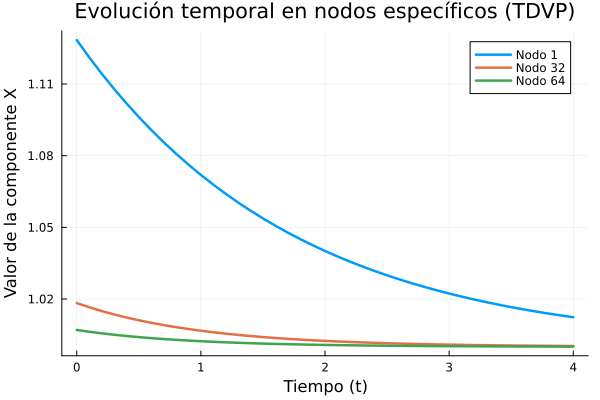

In [11]:
using Plots
gr() 

println("Generando gráfico de la evolución temporal por posiciones...")

# =========================================================================
# CONFIGURACIÓN DE NODOS A GRAFICAR
# =========================================================================
# Supongamos que N es el número total de nodos (filas en historia_X)
N = size(historia_X, 1)

# Puedes elegir manualmente qué nodos quieres ver, por ejemplo: [1, 5, 10]
# O una selección automática (por ejemplo, el primer nodo, el del medio y el último):
nodos_interes = [1, div(N, 2), N] 

# Vector de tiempos para el eje X
tiempos = 0.0:dt:t_total

# 1. Creamos el lienzo principal con los nuevos ejes
p = plot(
    title = "Evolución temporal en nodos específicos (TDVP)",
    xlabel = "Tiempo (t)",
    ylabel = "Valor de la componente X",
    lw = 2,
    legend = :topright,
    grid = true
)

# 2. Rellenamos el lienzo con la evolución de cada nodo seleccionado
for nodo in nodos_interes
    # Extraemos toda la fila correspondiente al nodo para todos los instantes de tiempo
    evolucion_nodo = historia_X[nodo, :]
    
    etiqueta = "Nodo $nodo"
    
    # Graficamos: Eje X = tiempos, Eje Y = evolución del nodo
    plot!(p, tiempos, evolucion_nodo, label = etiqueta, lw = 2.5)
end

# 3. MOSTRAR EN PANTALLA
display(p)
gui()